# Agentic AI - Reflection Pattern
The agent evaluates its own output against criteria (e.g., accuracy, tone, safety) and corrects itself iteratively before finalizing the response.

## Ollama Setup
So we will be using open source models from ollama as an llm/slm call to understand the concept

In [146]:
%%capture
# let's download the ollama executables
!curl -fsSL https://ollama.com/install.sh | sh


In [207]:
# serve the ollama
!nohup ollama serve &

nohup: appending output to 'nohup.out'


In [ ]:
# pull the llm/slm models
# !ollama pull llama3.2:1b
# !ollama pull smollm:135m
# !ollama pull embeddinggemma:300m
# !ollama pull tinyllama:1.1b
!ollama pull gemma3:1b
!ollama pull gemma3:270m

In [208]:
# list the pulled models
!ollama list

NAME           ID              SIZE      MODIFIED       
gemma3:1b      8648f39daa8f    815 MB    36 minutes ago    
gemma3:270m    e7d36fb2c3b3    291 MB    44 minutes ago    


## LangChain/LangGraph Framework
we will be using langchain framework to implement the agents

In [26]:
# Installing required libraries
%%capture

!pip install langchain
!pip install langchain-ollama
!pip install langchain-core
!pip install langgraph
!pip install mermaid-py
!pip install pprintpp

In [28]:
# importing required libs

from langgraph.graph import StateGraph, START, END
from langchain_ollama.llms import OllamaLLM
from langchain_core.prompts import ChatPromptTemplate
from typing import TypedDict
from IPython.display import Image
from pprint import pprint

In [148]:
# so for reflection we would need an llm to evaluate the response, we will be using two llm to achieve this,
# one will generate and another llm will evaluate it.

generate_llm = OllamaLLM(model="gemma3:270m")
grader_llm = OllamaLLM(model="gemma3:1b")

**Use Case:** We will be simply creating a workflow to generate the article on the user provided topic. However, we would make sure it should be professional, non-sensitive and follows ethics.

For this we will use two llm, one to generat the initial article and another as a grader to grade it. We will regenerate the article if it is not met the criteria.

Let's construct the graph elements

In [149]:
# state class
class AgentState(TypedDict):
  user_topic: str # to hold the user topic
  generator_response: str # to hold the generated article for user topic
  grader_response: str # grader, result as Yes or No
  action_required_for_generator: str # actions required for generator for correction



In [179]:
# article generator node


generator_prompt = ChatPromptTemplate.from_template(
"""
Act as a professional article writer for reputed newspaper.
You have to write a 100 words article as there is a space limit in the newspaper block.
The article must be crisp and cover most of the aspects. Your answer only contains the article text nothing else.
Here is the topic:
{user_topic}
"""
)

generator_chain = generator_prompt | generate_llm

def generate_article(agentState: AgentState):
  user_topic = agentState["user_topic"]

  generator_response = generator_chain.invoke({"user_topic": user_topic})
  # print("generator_response length: ", len(str(generator_response).split()))
  # agentState["generator_response"] = generator_response
  return {"generator_response" : generator_response }


In [204]:
# grader node to evaluate the generated article and then approve or ask for rewrite

grader_prompt = ChatPromptTemplate.from_template(
    """
    Act as a senior article reviewer in reputed newspaper media company.
    You have to review the article for given topic.
    At the end your answer must be either 'PASSED' or 'REWRITE' only.
    Here is the review paremeters:
    1. Article must be around 100 words only.
    2. Articel must follow the ethics, and should not be sensitive towards any group or people.
    3. There must not be many repetitive words or sentences.

    If any of the paramter is not satisfies then ask for 'REWRITE'

    Here is the topic {user_topic} and the article for review is '{generator_response}'
    """
)

grader_chain = grader_prompt | grader_llm

def grader_evalaution(agentState: AgentState):
  user_topic = agentState["user_topic"]
  generator_response = agentState["generator_response"]

  grader_response = grader_chain.invoke({"user_topic": user_topic, "generator_response" : generator_response})
  grader_response = str(grader_response).replace("\n","").strip()
  # print("modifying the code to test the scernario")
  # grader_response = "REWRITE"
  return {"grader_response" : grader_response }


In [205]:
# creating the decision router to decide if we have to end the flow or ask the generator again to regenerate the output

def decision_router(agentState: AgentState):
  grader_response = agentState["grader_response"]
  print("grader_response: ", grader_response)
  if grader_response == "PASSED":
    return "end_call"
  else:
    return "regenerate_call"


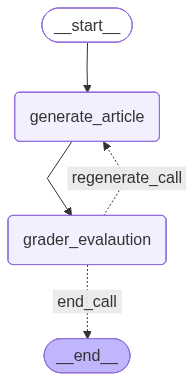

In [209]:
# let's add the node and edges

graph = StateGraph(AgentState)

graph.add_node(generate_article)
graph.add_node(grader_evalaution)


graph.add_edge(START, "generate_article")
graph.add_edge("generate_article", "grader_evalaution")
# graph.add_edge("grader_evalaution", END)



graph.add_conditional_edges(
    "grader_evalaution",
    decision_router,
    {
        "end_call": END,
        "regenerate_call": "generate_article"
    })



workflow = graph.compile()

Image(workflow.get_graph().draw_mermaid_png())

Let's invoke the model and see how it works

In [210]:
for chunk in workflow.stream({"user_topic":"Global Warming"}, stream_mode="values"):
  pprint(chunk)

{'user_topic': 'Global Warming'}
{'generator_response': '## Global Warming: A Growing Threat to Our Planet\n'
                       '\n'
                       'Global warming, once a distant threat, is now a '
                       'pervasive and accelerating reality, impacting our '
                       "planet's climate and ecosystems. Rising temperatures "
                       'are causing widespread damage, from melting glaciers '
                       'and sea levels to extreme weather events and '
                       'disruptions to agricultural production. The '
                       'consequences are far-reaching, threatening human '
                       'lives, economies, and the stability of global '
                       'societies. Addressing this crisis requires a concerted '
                       'global effort to reduce greenhouse gas emissions and '
                       'transition to a sustainable future.',
 'user_topic': 'Global Warming'}
grader_resp

In [211]:
for chunk in workflow.stream({"user_topic":"Smart Devices"}):
  pprint(chunk)

{'generate_article': {'generator_response': '## Smart Devices: Revolutionizing '
                                            'the Future\n'
                                            '\n'
                                            'The relentless march of '
                                            'technology has ushered in a new '
                                            'era of innovation, and smart '
                                            'devices are poised to redefine '
                                            'how we interact with technology '
                                            'and the world around us. From '
                                            'smart home appliances to '
                                            'sophisticated wearables, these '
                                            'devices offer a plethora of '
                                            'benefits, enhancing productivity, '
                                            '

Nice, let's look into the final input and output

In [212]:
final_output = workflow.invoke({"user_topic":"Agentic AI"})
print(f"Here is the article for given topic: {final_output['user_topic']} \nArticle: \n{final_output['generator_response']}")


grader_response:  PASSED
Here is the article for given topic: Agentic AI 
Article: 
## Agentic AI: Revolutionizing Business Operations

The rise of Artificial Intelligence (AI) is reshaping the business landscape, promising unprecedented efficiency and innovation. Agentic AI, a cutting-edge technology, is poised to revolutionize how businesses operate, automating tasks and optimizing processes. From streamlining customer interactions to enhancing data analysis, agentic AI offers significant potential to improve productivity, reduce costs, and enhance customer experience. As businesses continue to adapt to the evolving demands of the 21st century, understanding and leveraging the power of agentic AI will be crucial for success.
